# RGB/RC classification for bulge stars

The Cannon and BINGO age models are trained **per evolutionary state** (RGB vs red
clump), but bulge stars have no asteroseismology to tell the two apart. This notebook
trains a **spectroscopic** classifier on the APOKASC-labelled stars from the
AnniesLasso prep (`train_data/{rgb,rc}_clean_labels.parquet`, `EvoState_pred`
1 = RGB, 2 = RC) and applies it to a bulge catalog.

Design choices:

- **Features**: Teff, logg, [Fe/H], [Mg/Fe], [C/Fe], [N/Fe], [C/N] — the same Astra
  labels the bulge stars have, and the same family the age models use. RC stars
  separate from RGB via Kiel-diagram position plus the [C/N] mass proxy
  (cf. Ting, Hawkins & Rix 2018; Hawkins et al. 2018).
- **No photometry**: Gaia/2MASS colors in the bulge are extinction-dominated;
  a color-trained classifier would not transfer.
- **Validation**: `EvoState_pred` is itself an upstream prediction, so metrics are
  reported both on the full sample and on the **gold subset** with a seismic
  consensus `EvoState` (1 or 2).
- **Three-way output**: stars with `THR_LO < P(RC) < THR_HI` are flagged
  *ambiguous* rather than forced into a class — trading a few percent of the
  sample for ~96–97% purity on both sides.

Caveat for the bulge: it is more metal-rich than the Kepler field, so some stars
extrapolate beyond the training range; the apply step flags them (`in_domain`).

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

CANDIDATES = [
    '~/scr_mk27/bingo-modern',
    '~/code/bingo-modern',
    '.',
]
repo = next((p for p in map(os.path.expanduser, CANDIDATES)
             if os.path.isfile(os.path.join(p, 'prepare_dataset.py'))), None)
if repo is None:
    raise FileNotFoundError('Could not find the repo. Add its dir to CANDIDATES.')
repo = os.path.abspath(repo)
os.chdir(repo)
sys.path.insert(0, repo)
print('repo:', repo, '| sklearn:', sklearn.__version__)

repo: /Users/mjablons/code/bingo-modern | sklearn: 1.8.0


## 2. Configuration

In [2]:
RGB_LABELS = 'train_data/rgb_clean_labels.parquet'
RC_LABELS = 'train_data/rc_clean_labels.parquet'
OUTPUT_DIR = Path('./RGB_RC_classifier')
OUTPUT_DIR.mkdir(exist_ok=True)

# Bulge catalog to classify (Astra label convention assumed; adjust FEATURE_MAP
# in section 6 if the schema differs). Leave as-is on a machine without the data:
# the apply step skips gracefully.
BULGE_CATALOG = '~/scr_mk27/bulge-ages-and-orbits/data/bulge_sample.parquet'

SEED = 42
FEATS = ['raw_teff', 'raw_logg', 'raw_fe_h', 'mg_fe', 'c_fe', 'n_fe', 'c_n']
THR_LO, THR_HI = 0.3, 0.7   # P(RC) below/above => RGB/RC; between => ambiguous

# Regularized to generalize past EvoState_pred quirks: the unregularized model
# gains ~0 on the gold subset while fitting the full sample harder.
HGB_PARAMS = dict(max_leaf_nodes=15, l2_regularization=1.0, learning_rate=0.06,
                  random_state=SEED)

## 3. Load & label

Concatenate the two state files (file membership = label), drop the handful of
stars that appear in **both** (conflicting labels), and derive [C/N].

In [3]:
rgb = pd.read_parquet(RGB_LABELS).assign(is_rc=0)
rc = pd.read_parquet(RC_LABELS).assign(is_rc=1)
conflicts = set(rgb.APOGEE_ID) & set(rc.APOGEE_ID)
df = pd.concat([rgb, rc], ignore_index=True)
df = df[~df.APOGEE_ID.isin(conflicts)].reset_index(drop=True)
df['c_n'] = df['c_fe'] - df['n_fe']

before = len(df)
df = df.dropna(subset=FEATS).reset_index(drop=True)
X = df[FEATS].values
y = df['is_rc'].values
# Gold subset: seismic consensus EvoState available (1=RGB, 2=RC)
gold = df['EvoState'].isin([1.0, 2.0]).values

print(f'RGB: {(y == 0).sum()}  RC: {(y == 1).sum()}  '
      f'(dropped {len(conflicts)} conflicting IDs, {before - len(df)} NaN rows)')
print(f'Gold (seismic EvoState) subset: {gold.sum()} stars')

RGB: 1826  RC: 916  (dropped 2 conflicting IDs, 41 NaN rows)
Gold (seismic EvoState) subset: 921 stars


## 4. Cross-validated performance

5-fold `cross_val_predict` so every star is scored by a model that never saw it.
Metrics on the full sample and on the gold subset; then a threshold sweep for the
three-way (RGB / ambiguous / RC) decision.

In [4]:
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
clf_cv = HistGradientBoostingClassifier(**HGB_PARAMS)
p_cv = cross_val_predict(clf_cv, X, y, cv=cv, method='predict_proba')[:, 1]


def report(mask, label):
    yy, pp = y[mask], (p_cv[mask] > 0.5).astype(int)
    cm = confusion_matrix(yy, pp)
    rc_pur = cm[1, 1] / max(cm[0, 1] + cm[1, 1], 1)
    rc_com = cm[1, 1] / max(cm[1, 0] + cm[1, 1], 1)
    rgb_pur = cm[0, 0] / max(cm[0, 0] + cm[1, 0], 1)
    print(f'  [{label:4s}] n={mask.sum():4d}  acc={(pp == yy).mean():.3f}  '
          f'AUC={roc_auc_score(yy, p_cv[mask]):.3f}  '
          f'RC purity={rc_pur:.3f} compl={rc_com:.3f}  RGB purity={rgb_pur:.3f}')


print('Plain 0.5 threshold:')
report(np.ones(len(y), bool), 'all')
report(gold, 'gold')

print(f'\nThree-way decision (RGB if P<lo, RC if P>hi, else ambiguous):')
print(f"{'band':>10s} {'decided':>8s} {'RC pur':>7s} {'RGB pur':>8s}   (full sample)")
for lo, hi in [(0.5, 0.5), (0.4, 0.6), (0.3, 0.7), (0.2, 0.8)]:
    decided = (p_cv < lo) | (p_cv > hi)
    pred = (p_cv > hi).astype(int)
    yy, pp = y[decided], pred[decided]
    rc_pur = (yy[pp == 1] == 1).mean()
    rgb_pur = (yy[pp == 0] == 0).mean()
    mark = ' <- chosen' if (lo, hi) == (THR_LO, THR_HI) else ''
    print(f'  [{lo},{hi}] {decided.mean():8.1%} {rc_pur:7.3f} {rgb_pur:8.3f}{mark}')

Plain 0.5 threshold:
  [all ] n=2742  acc=0.944  AUC=0.982  RC purity=0.923 compl=0.907  RGB purity=0.954
  [gold] n= 921  acc=0.900  AUC=0.953  RC purity=0.878 compl=0.873  RGB purity=0.915

Three-way decision (RGB if P<lo, RC if P>hi, else ambiguous):
      band  decided  RC pur  RGB pur   (full sample)
  [0.5,0.5]   100.0%   0.923    0.954
  [0.4,0.6]    97.1%   0.940    0.963
  [0.3,0.7]    93.6%   0.960    0.969 <- chosen
  [0.2,0.8]    88.8%   0.976    0.976


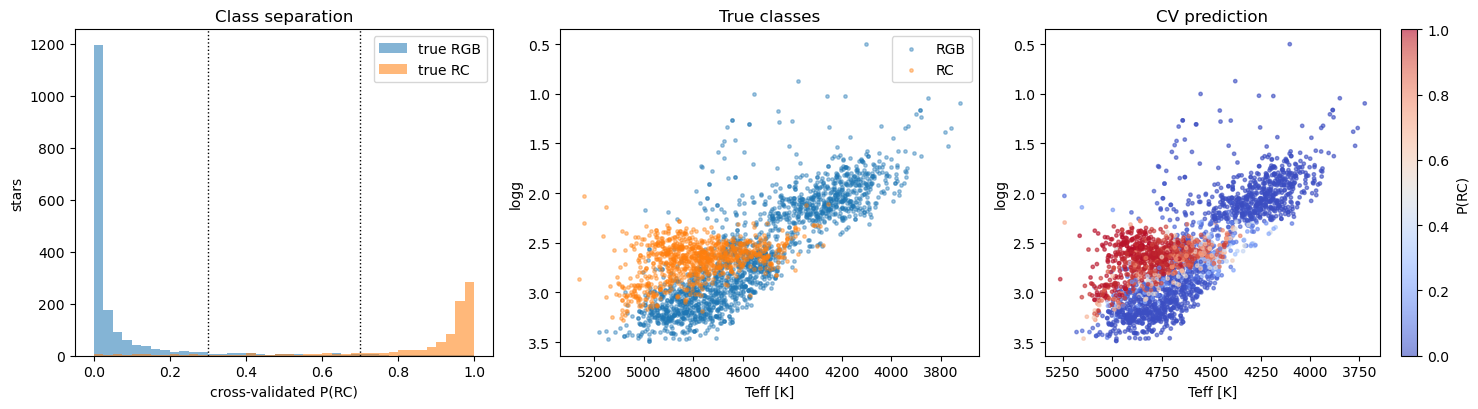

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# P(RC) distribution by true class
bins = np.linspace(0, 1, 41)
axes[0].hist(p_cv[y == 0], bins=bins, alpha=0.55, label='true RGB')
axes[0].hist(p_cv[y == 1], bins=bins, alpha=0.55, label='true RC')
for t in (THR_LO, THR_HI):
    axes[0].axvline(t, color='k', ls=':', lw=1)
axes[0].set_xlabel('cross-validated P(RC)')
axes[0].set_ylabel('stars')
axes[0].set_title('Class separation')
axes[0].legend()

# Kiel diagram: truth vs prediction confidence
for m, lbl, c in [(y == 0, 'RGB', 'tab:blue'), (y == 1, 'RC', 'tab:orange')]:
    axes[1].scatter(df['raw_teff'][m], df['raw_logg'][m], s=6, alpha=0.4,
                    color=c, label=lbl)
axes[1].legend()
axes[1].set_title('True classes')

sc = axes[2].scatter(df['raw_teff'], df['raw_logg'], s=6, alpha=0.6,
                     c=p_cv, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[2], label='P(RC)')
axes[2].set_title('CV prediction')

for ax in axes[1:]:
    ax.invert_xaxis()
    ax.invert_yaxis()
    ax.set_xlabel('Teff [K]')
    ax.set_ylabel('logg')

plt.tight_layout()
plt.show()

## 5. Final model & save

Fit on the full labelled sample, record permutation importances and the training
feature ranges (1st–99th percentile, used by the apply step's `in_domain` flag),
and save one joblib bundle.

In [6]:
clf = HistGradientBoostingClassifier(**HGB_PARAMS).fit(X, y)

imp = permutation_importance(clf, X, y, n_repeats=10, random_state=SEED)
print('Permutation importance (accuracy drop when shuffled):')
for f, m in sorted(zip(FEATS, imp.importances_mean), key=lambda t: -t[1]):
    print(f'  {f:10s} {m:.3f}')

domain = {f: (float(np.percentile(df[f], 1)), float(np.percentile(df[f], 99)))
          for f in FEATS}

bundle = {
    'model': clf,
    'features': FEATS,
    'thr_lo': THR_LO,
    'thr_hi': THR_HI,
    'domain_1_99': domain,      # training 1st-99th pct per feature
    'sklearn_version': sklearn.__version__,
    'n_train': len(df),
    'label_convention': 'P(RC): is_rc=1 for red clump, 0 for RGB',
}
joblib.dump(bundle, OUTPUT_DIR / 'rgb_rc_classifier.pkl')
print(f"\nSaved {OUTPUT_DIR / 'rgb_rc_classifier.pkl'}")

Permutation importance (accuracy drop when shuffled):
  raw_logg   0.285
  raw_teff   0.206
  raw_fe_h   0.061
  c_fe       0.050
  mg_fe      0.034
  n_fe       0.009
  c_n        0.006

Saved RGB_RC_classifier/rgb_rc_classifier.pkl


## 6. Apply to the bulge catalog

Classify the bulge stars and write **one CSV per class** in the schema the age
pipelines expect (`APOGEE_ID`, `FOO`/`FOO_ERR` pairs), so
`bulge_rgb_bnn.parquet` feeds the RGB pipeline / Cannon model and `bulge_rc_bnn.parquet`
the RC one. Ambiguous stars (`THR_LO ≤ P(RC) ≤ THR_HI`, ~6% in CV) are **dropped**:
purity of the age samples matters more than completeness here.

`in_domain` is False where any feature falls outside the training 1st–99th
percentile range (expected for the most metal-rich bulge stars): treat those
classifications — and the downstream ages — with caution.

In [7]:
# Astra label convention -> the FOO/FOO_ERR schema used by prepare_dataset.py
# (same mapping as convert_seismic_dataset.py). Adjust if the bulge schema differs.
FEATURE_MAP = {
    'APOGEE_ID': 'APOGEE_ID',
    'raw_teff': 'TEFF', 'raw_e_teff': 'TEFF_ERR',
    'raw_logg': 'LOGG', 'raw_e_logg': 'LOGG_ERR',
    'raw_fe_h': 'FE_H', 'raw_e_fe_h': 'FE_H_ERR',
    'mg_fe': 'MG_FE', 'e_mg_fe': 'MG_FE_ERR',
    'c_fe': 'C_FE', 'e_c_fe': 'C_FE_ERR',
    'n_fe': 'N_FE', 'e_n_fe': 'N_FE_ERR',
}

bulge_path = Path(os.path.expanduser(BULGE_CATALOG))
if not bulge_path.exists():
    print(f'Bulge catalog not found at {bulge_path} -- set BULGE_CATALOG (section 2)')
else:
    read = pd.read_parquet if bulge_path.suffix == '.parquet' else pd.read_csv
    bulge = read(bulge_path)
    bulge['c_n'] = bulge['c_fe'] - bulge['n_fe']

    usable = bulge.dropna(subset=FEATS).reset_index(drop=True)
    print(f'{len(bulge)} bulge stars, {len(usable)} with all classifier features')

    p_rc = clf.predict_proba(usable[FEATS].values)[:, 1]
    usable['p_rc'] = p_rc
    usable['evo_class'] = np.select(
        [p_rc < THR_LO, p_rc > THR_HI], ['RGB', 'RC'], default='ambiguous')
    usable['in_domain'] = np.all(
        [(usable[f] >= lo) & (usable[f] <= hi)
         for f, (lo, hi) in bundle['domain_1_99'].items()], axis=0)

    print(usable['evo_class'].value_counts().to_string())
    print(f"in_domain: {usable['in_domain'].mean():.1%}")

    n_amb = (usable['evo_class'] == 'ambiguous').sum()
    print(f'Dropping {n_amb} ambiguous stars ({n_amb / len(usable):.1%})')

    out = usable.rename(columns=FEATURE_MAP)
    keep = list(FEATURE_MAP.values()) + ['p_rc', 'evo_class', 'in_domain']
    for cls, fname in [('RGB', 'bulge_rgb_bnn.parquet'), ('RC', 'bulge_rc_bnn.parquet')]:
        sel = out.loc[out['evo_class'] == cls, keep]
        sel.to_parquet(OUTPUT_DIR / fname, index=False)
        print(f'{OUTPUT_DIR / fname}: {len(sel)} stars')

Bulge catalog not found at /Users/mjablons/scr_mk27/bulge-ages-and-orbits/data/bulge_sample.parquet -- set BULGE_CATALOG (section 2)
